# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

MDSR 10.6.6은 `NHANES` 자료에서 20세 이상 성인을 대상으로 현재 흡연
여부를 예측하는 로지스틱 회귀 모형을 만드는 문제이다. `SmokeNow`는
과거에 100개비 이상 피운 사람에게만 기록되므로, 현재 흡연 여부는 다음과
같이 재코딩한다.

- `SmokeNow == "Yes"`: 현재 흡연자
- `SmokeNow == "No"`: 과거 흡연 경험은 있으나 현재는 비흡연자
- `Smoke100 == "No"`: 평생 100개비 미만 흡연자이므로 현재 비흡연자

## R

``` r
library(dplyr)
library(ggplot2)
library(broom)

NHANES <- read.csv(find_data_file("NHANES.csv"), na.strings = c("", "NA"))

smoking <- NHANES |>
  filter(Age >= 20) |>
  mutate(
    current_smoker = case_when(
      SmokeNow == "Yes" ~ 1,
      SmokeNow == "No" ~ 0,
      Smoke100 == "No" ~ 0,
      TRUE ~ NA_real_
    ),
    Gender = factor(Gender),
    Education = factor(Education),
    PhysActive = factor(PhysActive),
    BMI = as.numeric(BMI),
    AlcoholDay = as.numeric(AlcoholDay),
    SleepHrsNight = as.numeric(SleepHrsNight)
  ) |>
  filter(
    !is.na(current_smoker),
    !is.na(Age),
    !is.na(Gender),
    !is.na(BMI),
    !is.na(Education),
    !is.na(PhysActive),
    !is.na(AlcoholDay),
    !is.na(SleepHrsNight)
  )

cat("분석 표본 수:", nrow(smoking), "\n")
```

    분석 표본 수: 4782 

``` r
cat("현재 흡연자 수:", sum(smoking$current_smoker), "\n")
```

    현재 흡연자 수: 1054 

``` r
cat("현재 흡연율:", mean(smoking$current_smoker), "\n\n")
```

    현재 흡연율: 0.2204099 

``` r
print(
  smoking |>
    group_by(current_smoker) |>
    summarise(
      n = n(),
      mean_age = mean(Age),
      mean_BMI = mean(BMI),
      mean_alcohol_day = mean(AlcoholDay),
      mean_sleep = mean(SleepHrsNight),
      .groups = "drop"
    )
)
```

    # A tibble: 2 × 6
      current_smoker     n mean_age mean_BMI mean_alcohol_day mean_sleep
               <dbl> <int>    <dbl>    <dbl>            <dbl>      <dbl>
    1              0  3728     46.7     28.7             2.49       6.99
    2              1  1054     41.6     27.7             4.23       6.61

``` r
ggplot(smoking, aes(x = Age, fill = factor(current_smoker))) +
  geom_histogram(position = "identity", alpha = 0.45, bins = 30) +
  scale_fill_manual(
    values = c("gray70", "firebrick"),
    labels = c("비흡연", "현재 흡연"),
    name = "현재 흡연"
  ) +
  labs(
    title = "20세 이상 성인의 연령별 현재 흡연 분포",
    x = "나이",
    y = "빈도"
  ) +
  theme_bw()
```

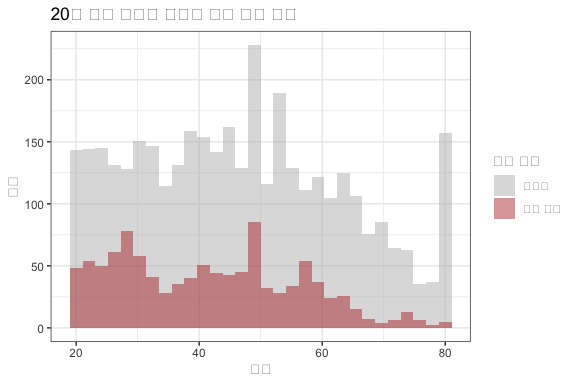

``` r
fit_smoke <- glm(
  current_smoker ~ Age + Gender + BMI + Education +
    PhysActive + AlcoholDay + SleepHrsNight,
  data = smoking,
  family = binomial()
)

cat("\n로지스틱 회귀 모형 요약:\n")
```


    로지스틱 회귀 모형 요약:

``` r
print(summary(fit_smoke))
```


    Call:
    glm(formula = current_smoker ~ Age + Gender + BMI + Education + 
        PhysActive + AlcoholDay + SleepHrsNight, family = binomial(), 
        data = smoking)

    Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
    (Intercept)              2.306732   0.359072   6.424 1.33e-10 ***
    Age                     -0.016323   0.002537  -6.433 1.25e-10 ***
    Gendermale               0.013121   0.079797   0.164    0.869    
    BMI                     -0.048148   0.006374  -7.554 4.23e-14 ***
    Education9 - 11th Grade  0.387476   0.195033   1.987    0.047 *  
    EducationCollege Grad   -1.337820   0.201091  -6.653 2.88e-11 ***
    EducationHigh School    -0.063166   0.187737  -0.336    0.737    
    EducationSome College   -0.279298   0.184208  -1.516    0.129    
    PhysActiveYes           -0.596027   0.080760  -7.380 1.58e-13 ***
    AlcoholDay               0.133097   0.014889   8.939  < 2e-16 ***
    SleepHrsNight           -0.181215   0.029173  -6.212 5.24e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 5044.3  on 4781  degrees of freedom
    Residual deviance: 4331.2  on 4771  degrees of freedom
    AIC: 4353.2

    Number of Fisher Scoring iterations: 5

``` r
cat("\n오즈비와 95% 신뢰구간:\n")
```


    오즈비와 95% 신뢰구간:

``` r
print(
  tidy(fit_smoke, conf.int = TRUE, exponentiate = TRUE) |>
    select(term, estimate, conf.low, conf.high, p.value)
)
```

    # A tibble: 11 × 5
       term                    estimate conf.low conf.high  p.value
       <chr>                      <dbl>    <dbl>     <dbl>    <dbl>
     1 (Intercept)               10.0      4.97     20.3   1.33e-10
     2 Age                        0.984    0.979     0.989 1.25e-10
     3 Gendermale                 1.01     0.866     1.18  8.69e- 1
     4 BMI                        0.953    0.941     0.965 4.23e-14
     5 Education9 - 11th Grade    1.47     1.01      2.17  4.70e- 2
     6 EducationCollege Grad      0.262    0.177     0.391 2.88e-11
     7 EducationHigh School       0.939    0.653     1.36  7.37e- 1
     8 EducationSome College      0.756    0.530     1.09  1.29e- 1
     9 PhysActiveYes              0.551    0.470     0.645 1.58e-13
    10 AlcoholDay                 1.14     1.11      1.18  3.91e-19
    11 SleepHrsNight              0.834    0.788     0.883 5.24e-10

``` r
smoking <- smoking |>
  mutate(
    pred_prob = predict(fit_smoke, type = "response"),
    pred_class = as.integer(pred_prob >= 0.5)
  )

conf_mat <- table(
  observed = smoking$current_smoker,
  predicted = smoking$pred_class
)

cat("\n0.5 기준 혼동행렬:\n")
```


    0.5 기준 혼동행렬:

``` r
print(conf_mat)
```

            predicted
    observed    0    1
           0 3584  144
           1  871  183

``` r
accuracy <- mean(smoking$current_smoker == smoking$pred_class)
sensitivity <- conf_mat["1", "1"] / sum(conf_mat["1", ])
specificity <- conf_mat["0", "0"] / sum(conf_mat["0", ])

cat("\n정확도:", accuracy, "\n")
```


    정확도: 0.7877457 

``` r
cat("민감도:", sensitivity, "\n")
```

    민감도: 0.1736243 

``` r
cat("특이도:", specificity, "\n")
```

    특이도: 0.9613734 

``` r
ggplot(smoking, aes(x = pred_prob, fill = factor(current_smoker))) +
  geom_histogram(position = "identity", alpha = 0.45, bins = 35) +
  scale_fill_manual(
    values = c("gray70", "firebrick"),
    labels = c("비흡연", "현재 흡연"),
    name = "관측값"
  ) +
  labs(
    title = "현재 흡연 예측확률 분포",
    x = "예측확률",
    y = "빈도"
  ) +
  theme_bw()
```

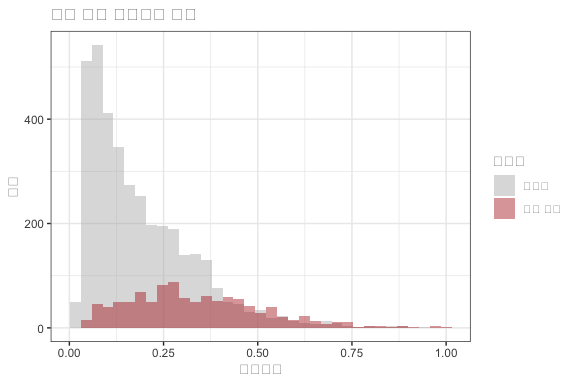

``` r
cat("\n해석:\n")
```


    해석:

``` r
cat("나이, BMI, 활동 여부, 음주량, 수면시간, 교육수준을 함께 고려하면 현재 흡연 여부를 어느 정도 설명할 수 있다.\n")
```

    나이, BMI, 활동 여부, 음주량, 수면시간, 교육수준을 함께 고려하면 현재 흡연 여부를 어느 정도 설명할 수 있다.

``` r
cat("나이와 BMI가 증가할수록 현재 흡연 오즈는 낮아지는 경향이 있고, 활동적이라고 응답한 사람도 현재 흡연 오즈가 낮다.\n")
```

    나이와 BMI가 증가할수록 현재 흡연 오즈는 낮아지는 경향이 있고, 활동적이라고 응답한 사람도 현재 흡연 오즈가 낮다.

``` r
cat("반대로 하루 음주량이 많을수록 현재 흡연 오즈가 증가한다.\n")
```

    반대로 하루 음주량이 많을수록 현재 흡연 오즈가 증가한다.

``` r
cat("대학 졸업 집단은 기준 교육수준 집단보다 현재 흡연 오즈가 크게 낮게 추정된다.\n")
```

    대학 졸업 집단은 기준 교육수준 집단보다 현재 흡연 오즈가 크게 낮게 추정된다.

``` r
cat("다만 0.5 절단값을 쓰면 현재 흡연자의 비율이 낮기 때문에 특이도는 높고 민감도는 낮다.\n")
```

    다만 0.5 절단값을 쓰면 현재 흡연자의 비율이 낮기 때문에 특이도는 높고 민감도는 낮다.

## Python

``` python
rows = read_csv_rows("NHANES.csv")

def clean_category(x):
    s = (x or "").strip()
    if s in {"", "NA", "<NA>", "nan", "NaN"}:
        return ""
    return s

analysis_rows = []
for r in rows:
    age = as_float(r.get("Age"))
    bmi = as_float(r.get("BMI"))
    alcohol = as_float(r.get("AlcoholDay"))
    sleep = as_float(r.get("SleepHrsNight"))
    gender = clean_category(r.get("Gender"))
    education = clean_category(r.get("Education"))
    phys = clean_category(r.get("PhysActive"))
    smoke_now = clean_category(r.get("SmokeNow"))
    smoke100 = clean_category(r.get("Smoke100"))

    if smoke_now == "Yes":
        y = 1
    elif smoke_now == "No" or smoke100 == "No":
        y = 0
    else:
        y = None

    if (
        age is None or age < 20 or bmi is None or alcohol is None or
        sleep is None or gender == "" or education == "" or phys == "" or
        y is None
    ):
        continue

    analysis_rows.append({
        "y": y,
        "Age": age,
        "BMI": bmi,
        "AlcoholDay": alcohol,
        "SleepHrsNight": sleep,
        "Gender": gender,
        "Education": education,
        "PhysActive": phys,
    })

education_levels = sorted({r["Education"] for r in analysis_rows})
base_education = education_levels[0]

names = [
    "Intercept",
    "Age",
    "Gender_male",
    "BMI",
] + [f"Education_{lev}" for lev in education_levels if lev != base_education] + [
    "PhysActive_Yes",
    "AlcoholDay",
    "SleepHrsNight",
]

X = []
y = []
for r in analysis_rows:
    row = [
        1.0,
        r["Age"],
        1.0 if r["Gender"] == "male" else 0.0,
        r["BMI"],
    ]
    row.extend(1.0 if r["Education"] == lev else 0.0 for lev in education_levels if lev != base_education)
    row.extend([
        1.0 if r["PhysActive"] == "Yes" else 0.0,
        r["AlcoholDay"],
        r["SleepHrsNight"],
    ])
    X.append(row)
    y.append(r["y"])

fit = fit_binomial_glm(X, y, [1.0] * len(y))

print("분석 표본 수:", len(y))
```

    분석 표본 수: 4782

``` python
print("현재 흡연자 수:", sum(y))
```

    현재 흡연자 수: 1054

``` python
print("현재 흡연율:", sum(y) / len(y))
```

    현재 흡연율: 0.22040987034713508

``` python
print("교육수준 기준범주:", base_education)
```

    교육수준 기준범주: 8th Grade

``` python
print()
```

``` python
print_coef_table(names, fit, odds_ratios=True)
```

    term                          estimate        se          z       p       ci_low      ci_high
    Intercept                        2.3067     0.3591     6.424  0.0000      1.6030      3.0105
    Age                             -0.0163     0.0025    -6.433  0.0000     -0.0213     -0.0113
    Gender_male                      0.0131     0.0798     0.164  0.8694     -0.1433      0.1695
    BMI                             -0.0481     0.0064    -7.554  0.0000     -0.0606     -0.0357
    Education_9 - 11th Grade         0.3875     0.1950     1.987  0.0470      0.0052      0.7697
    Education_College Grad          -1.3378     0.2011    -6.653  0.0000     -1.7320     -0.9437
    Education_High School           -0.0632     0.1877    -0.336  0.7365     -0.4311      0.3048
    Education_Some College          -0.2793     0.1842    -1.516  0.1295     -0.6403      0.0818
    PhysActive_Yes                  -0.5960     0.0808    -7.380  0.0000     -0.7543     -0.4377
    AlcoholDay                       0.1331     0.0149     8.939  0.0000      0.1039      0.1623
    SleepHrsNight                   -0.1812     0.0292    -6.212  0.0000     -0.2384     -0.1240

    Odds ratio scale:
    Intercept                    OR=  10.042, 95% CI=(   4.968,   20.298)
    Age                          OR=   0.984, 95% CI=(   0.979,    0.989)
    Gender_male                  OR=   1.013, 95% CI=(   0.867,    1.185)
    BMI                          OR=   0.953, 95% CI=(   0.941,    0.965)
    Education_9 - 11th Grade     OR=   1.473, 95% CI=(   1.005,    2.159)
    Education_College Grad       OR=   0.262, 95% CI=(   0.177,    0.389)
    Education_High School        OR=   0.939, 95% CI=(   0.650,    1.356)
    Education_Some College       OR=   0.756, 95% CI=(   0.527,    1.085)
    PhysActive_Yes               OR=   0.551, 95% CI=(   0.470,    0.645)
    AlcoholDay                   OR=   1.142, 95% CI=(   1.110,    1.176)
    SleepHrsNight                OR=   0.834, 95% CI=(   0.788,    0.883)

``` python
pred = [1 if p >= 0.5 else 0 for p in fit["mu"]]
tn = sum(1 for obs, pr in zip(y, pred) if obs == 0 and pr == 0)
fp = sum(1 for obs, pr in zip(y, pred) if obs == 0 and pr == 1)
fn = sum(1 for obs, pr in zip(y, pred) if obs == 1 and pr == 0)
tp = sum(1 for obs, pr in zip(y, pred) if obs == 1 and pr == 1)

print("\n0.5 기준 혼동행렬")
```


    0.5 기준 혼동행렬

``` python
print("          predicted 0  predicted 1")
```

              predicted 0  predicted 1

``` python
print(f"observed 0 {tn:11d} {fp:12d}")
```

    observed 0        3584          144

``` python
print(f"observed 1 {fn:11d} {tp:12d}")
```

    observed 1         871          183

``` python
print("정확도:", (tn + tp) / len(y))
```

    정확도: 0.787745713090757

``` python
print("민감도:", tp / (tp + fn))
```

    민감도: 0.17362428842504743

``` python
print("특이도:", tn / (tn + fp))
```

    특이도: 0.9613733905579399

``` python
print("\n해석:")
```


    해석:

``` python
print("Python에서도 R과 같은 재코딩과 같은 설명변수를 사용했다.")
```

    Python에서도 R과 같은 재코딩과 같은 설명변수를 사용했다.

``` python
print("계수의 부호는 R 분석과 동일하게 나이, BMI, 신체활동, 수면시간은 음의 방향이고 하루 음주량은 양의 방향이다.")
```

    계수의 부호는 R 분석과 동일하게 나이, BMI, 신체활동, 수면시간은 음의 방향이고 하루 음주량은 양의 방향이다.

``` python
print("0.5 절단값에서는 현재 흡연자를 많이 놓치므로, 예측 목적이라면 ROC 곡선 등을 이용해 절단값을 조정할 필요가 있다.")
```

    0.5 절단값에서는 현재 흡연자를 많이 놓치므로, 예측 목적이라면 ROC 곡선 등을 이용해 절단값을 조정할 필요가 있다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

여기서는 한 행을 한 팀-연도(`teamID`, `yearID`)로 두고 분석하였다.
2020년을 제외한 2010–2025년 자료는 450개 팀-연도이며, `teamID`와
`yearID` 조합은 모두 고유하다.

## R

``` r
library(dplyr)
library(ggplot2)
library(broom)

Teams <- read.csv(find_data_file("Teams.csv"))

team_recent <- Teams |>
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) |>
  transmute(
    yearID,
    teamID,
    W,
    L,
    G = W + L,
    RS = R,
    RA,
    WPct = W / (W + L),
    run_ratio = RS / RA,
    log_ratio = log(RS / RA),
    logRS = log(RS),
    logRA = log(RA)
  ) |>
  filter(RS > 0, RA > 0)

cat("분석 관측치 수:", nrow(team_recent), "\n")
```

    분석 관측치 수: 450 

``` r
cat("teamID-yearID 고유 조합 수:", nrow(distinct(team_recent, teamID, yearID)), "\n")
```

    teamID-yearID 고유 조합 수: 450 

``` r
# 1. Bill James/Pythagorean 모형의 k 추정
fit_k <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data = team_recent,
  start = list(k = 2)
)

cat("\n비선형 모형의 k 추정:\n")
```


    비선형 모형의 k 추정:

``` r
print(summary(fit_k))
```


    Formula: WPct ~ 1/(1 + (RA/RS)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.515e-07

``` r
print(confint.default(fit_k))
```

         2.5 %  97.5 %
    k 1.695279 1.81031

``` r
team_recent <- team_recent |>
  mutate(WPct_hat_nls = predict(fit_k))

ggplot(team_recent, aes(x = run_ratio, y = WPct)) +
  geom_point(alpha = 0.5) +
  geom_line(
    aes(y = WPct_hat_nls),
    data = team_recent |> arrange(run_ratio),
    color = "blue",
    linewidth = 1
  ) +
  geom_hline(yintercept = 0.5, linetype = 2, color = "gray50") +
  geom_vline(xintercept = 1, linetype = 2, color = "gray50") +
  labs(
    title = "득점/실점 비율과 승률",
    subtitle = "Pythagorean 모형의 k를 추정",
    x = "RS / RA",
    y = "WPct"
  ) +
  theme_bw()
```

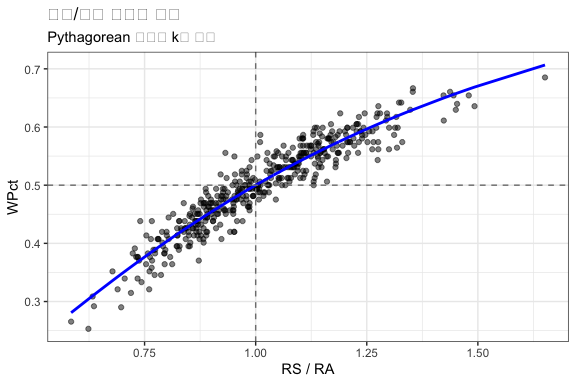

``` r
# 2. logit(WPct) = beta_1 * log(RS/RA), no intercept
fit_logit <- glm(
  cbind(W, L) ~ 0 + log_ratio,
  data = team_recent,
  family = binomial()
)

cat("\n절편 없는 로지스틱 회귀:\n")
```


    절편 없는 로지스틱 회귀:

``` r
print(summary(fit_logit))
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_ratio, family = binomial(), 
        data = team_recent)

    Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
    log_ratio  1.75320    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
print(confint.default(fit_logit))
```

                 2.5 %   97.5 %
    log_ratio 1.663795 1.842612

``` r
cat("\n비교:\n")
```


    비교:

``` r
cat("nls k =", coef(fit_k)["k"], "\n")
```

    nls k = 1.752794 

``` r
cat("logit beta_1 =", coef(fit_logit)["log_ratio"], "\n")
```

    logit beta_1 = 1.753203 

``` r
cat("두 값은 모두 RS/RA가 승률 로짓에 미치는 기울기이므로 거의 같은 값을 갖는다.\n")
```

    두 값은 모두 RS/RA가 승률 로짓에 미치는 기울기이므로 거의 같은 값을 갖는다.

``` r
# 3. 진단
dev_p <- pchisq(
  deviance(fit_logit),
  df.residual(fit_logit),
  lower.tail = FALSE
)

cat("\nResidual deviance:", deviance(fit_logit), "\n")
```


    Residual deviance: 180.2632 

``` r
cat("Residual df:", df.residual(fit_logit), "\n")
```

    Residual df: 449 

``` r
cat("카이제곱 비교 p-value:", dev_p, "\n")
```

    카이제곱 비교 p-value: 1 

``` r
diagnostics <- team_recent |>
  mutate(
    eta = predict(fit_logit, type = "link"),
    WPct_hat_logit = predict(fit_logit, type = "response"),
    dev_resid = residuals(fit_logit, type = "deviance")
  )

ggplot(diagnostics, aes(x = eta, y = dev_resid)) +
  geom_point(alpha = 0.55) +
  geom_hline(yintercept = 0, linetype = 2, color = "gray50") +
  labs(
    title = "Deviance residuals vs linear predictor",
    x = expression(eta),
    y = "Deviance residual"
  ) +
  theme_bw()
```

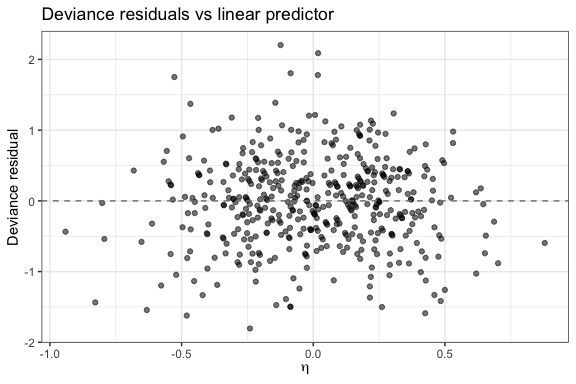

``` r
ggplot(diagnostics, aes(x = WPct_hat_logit, y = WPct)) +
  geom_point(alpha = 0.55) +
  geom_abline(slope = 1, intercept = 0, color = "blue") +
  labs(
    title = "관측 승률과 예측 승률 비교",
    x = "예측 WPct",
    y = "관측 WPct"
  ) +
  theme_bw()
```

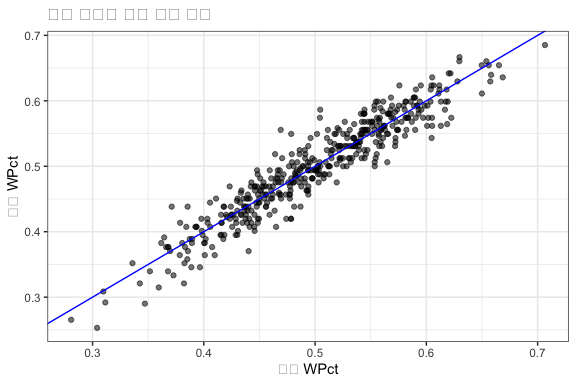

``` r
cat("\n진단 해석:\n")
```


    진단 해석:

``` r
cat("Residual deviance가 자유도보다 매우 작아 카이제곱 기준으로 나쁜 적합이라고 보기 어렵다.\n")
```

    Residual deviance가 자유도보다 매우 작아 카이제곱 기준으로 나쁜 적합이라고 보기 어렵다.

``` r
cat("잔차 그림에서도 뚜렷한 곡선 패턴은 크지 않고, 관측 승률과 예측 승률은 45도선 주변에 분포한다.\n")
```

    잔차 그림에서도 뚜렷한 곡선 패턴은 크지 않고, 관측 승률과 예측 승률은 45도선 주변에 분포한다.

``` r
# 4. log(RA), log(RS)를 따로 넣은 절편 없는 로지스틱 회귀
fit_two_logs <- glm(
  cbind(W, L) ~ 0 + logRA + logRS,
  data = team_recent,
  family = binomial()
)

cat("\nlogRA와 logRS를 따로 넣은 절편 없는 로지스틱 회귀:\n")
```


    logRA와 logRS를 따로 넣은 절편 없는 로지스틱 회귀:

``` r
print(summary(fit_two_logs))
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + logRA + logRS, family = binomial(), 
        data = team_recent)

    Coefficients:
          Estimate Std. Error z value Pr(>|z|)    
    logRA -1.75356    0.04563  -38.43   <2e-16 ***
    logRS  1.75315    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.13  on 448  degrees of freedom
    AIC: 2667.4

    Number of Fisher Scoring iterations: 3

``` r
print(confint.default(fit_two_logs))
```

              2.5 %    97.5 %
    logRA -1.842993 -1.664129
    logRS  1.663742  1.842563

``` r
cat("\n해석:\n")
```


    해석:

``` r
cat("Pythagorean 모형이 정확하다면 logRS의 계수는 +k, logRA의 계수는 -k에 가까워야 한다.\n")
```

    Pythagorean 모형이 정확하다면 logRS의 계수는 +k, logRA의 계수는 -k에 가까워야 한다.

``` r
cat("실제로 logRS와 logRA 계수는 크기가 거의 같고 부호가 반대이므로 1항 및 2항과 매우 유사한 모형을 얻었다.\n")
```

    실제로 logRS와 logRA 계수는 크기가 거의 같고 부호가 반대이므로 1항 및 2항과 매우 유사한 모형을 얻었다.

## Python

``` python
teams = recent_team_rows()

def sse_for_k(k):
    total = 0.0
    for r in teams:
        pred = 1 / (1 + (r["RA"] / r["RS"]) ** k)
        total += (r["WPct"] - pred) ** 2
    return total

k_hat = golden_minimize(sse_for_k, 0.1, 4.0)
sse = sse_for_k(k_hat)

deriv_sq_sum = 0.0
for r in teams:
    a = r["RA"] / r["RS"]
    ak = a ** k_hat
    deriv = -(ak * math.log(a)) / ((1 + ak) ** 2)
    deriv_sq_sum += deriv ** 2

sigma2 = sse / (len(teams) - 1)
se_k = math.sqrt(sigma2 / deriv_sq_sum)

print("분석 관측치 수:", len(teams))
```

    분석 관측치 수: 450

``` python
print("비선형 모형 k:", k_hat)
```

    비선형 모형 k: 1.7527938618467498

``` python
print("k의 근사 95% 신뢰구간:", (k_hat - 1.96 * se_k, k_hat + 1.96 * se_k))
```

    k의 근사 95% 신뢰구간: (1.6952773036434932, 1.8103104200500064)

``` python
X = [[r["log_ratio"]] for r in teams]
W = [r["W"] for r in teams]
G = [r["G"] for r in teams]
fit_logit_py = fit_binomial_glm(X, W, G)

print("\n절편 없는 로지스틱 회귀:")
```


    절편 없는 로지스틱 회귀:

``` python
print_coef_table(["log_ratio"], fit_logit_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    log_ratio                        1.7532     0.0456    38.433  0.0000      1.6638      1.8426

``` python
print("Residual deviance:", fit_logit_py["deviance"])
```

    Residual deviance: 180.26317935255148

``` python
print("Residual df:", fit_logit_py["df_resid"])
```

    Residual df: 449

``` python
X_two = [[r["logRA"], r["logRS"]] for r in teams]
fit_two_py = fit_binomial_glm(X_two, W, G)

print("\nlogRA와 logRS를 따로 넣은 모형:")
```


    logRA와 logRS를 따로 넣은 모형:

``` python
print_coef_table(["logRA", "logRS"], fit_two_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    logRA                           -1.7536     0.0456   -38.430  0.0000     -1.8430     -1.6641
    logRS                            1.7532     0.0456    38.431  0.0000      1.6637      1.8426

``` python
print("\n해석:")
```


    해석:

``` python
print("Python의 k 추정과 로지스틱 회귀 기울기는 R 결과와 같은 수준이다.")
```

    Python의 k 추정과 로지스틱 회귀 기울기는 R 결과와 같은 수준이다.

``` python
print("logRA와 logRS를 분리해도 두 계수는 크기가 거의 같고 부호가 반대여서 Pythagorean 모형과 같은 구조를 보인다.")
```

    logRA와 logRS를 분리해도 두 계수는 크기가 거의 같고 부호가 반대여서 Pythagorean 모형과 같은 구조를 보인다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

문제 2-1의 Pythagorean 모형은 득점과 실점만 사용한다. 여기서는 공격,
수비, 투수 지표를 함께 넣은 뒤 AIC 기준 단계별 선택을 적용한다.

## R

``` r
library(dplyr)
library(broom)
library(MASS)

Teams <- read.csv(find_data_file("Teams.csv"))

team_model <- Teams |>
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) |>
  mutate(
    G = W + L,
    WPct = W / G,
    logRS = log(R),
    logRA = log(RA),
    log_ratio = log(R / RA)
  ) |>
  dplyr::select(
    yearID, teamID, W, L, G, WPct, log_ratio, logRS, logRA,
    H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
    ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
    E, DP, FP, SV
  ) |>
  filter(if_all(everything(), ~ !is.na(.)))

predictors <- c(
  "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
  "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
  "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
)

full_formula <- as.formula(
  paste("cbind(W, L) ~", paste(predictors, collapse = " + "))
)

fit_full <- glm(
  full_formula,
  data = team_model,
  family = binomial()
)

fit_step <- MASS::stepAIC(fit_full, trace = FALSE)

cat("전체 모형 AIC:", AIC(fit_full), "\n")
```

    전체 모형 AIC: 2627.2 

``` r
cat("단계선택 모형 AIC:", AIC(fit_step), "\n")
```

    단계선택 모형 AIC: 2601.364 

``` r
cat("\n단계선택 결과 공식:\n")
```


    단계선택 결과 공식:

``` r
print(formula(fit_step))
```

    cbind(W, L) ~ logRS + logRA + CG + SHO + SV

``` r
cat("\n단계선택 모형 요약:\n")
```


    단계선택 모형 요약:

``` r
print(summary(fit_step))
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial(), 
        data = team_model)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
cat("\n단계선택 모형에서 한 변수씩 제거했을 때:\n")
```


    단계선택 모형에서 한 변수씩 제거했을 때:

``` r
print(drop1(fit_step, test = "Chisq"))
```

    Single term deletions

    Model:
    cbind(W, L) ~ logRS + logRA + CG + SHO + SV
           Df Deviance    AIC    LRT Pr(>Chi)    
    <none>      106.12 2601.4                    
    logRS   1   616.29 3109.5 510.17  < 2e-16 ***
    logRA   1   266.78 2760.0 160.66  < 2e-16 ***
    CG      1   108.42 2601.7   2.30  0.12919    
    SHO     1   109.52 2602.8   3.40  0.06502 .  
    SV      1   176.50 2669.8  70.38  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# 단계선택 결과의 CG는 p-value가 크고 제거해도 AIC 차이가 매우 작다.
# 해석 가능성과 간결성을 위해 CG를 제거한 모형을 최종 모형으로 둔다.
fit_final <- glm(
  cbind(W, L) ~ logRS + logRA + SHO + SV,
  data = team_model,
  family = binomial()
)

fit_pyth <- glm(
  cbind(W, L) ~ 0 + log_ratio,
  data = team_model,
  family = binomial()
)

cat("\n최종 모형 요약:\n")
```


    최종 모형 요약:

``` r
print(summary(fit_final))
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + SHO + SV, family = binomial(), 
        data = team_model)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.359663   0.812721  -2.903  0.00369 ** 
    logRS        1.606237   0.071629  22.424  < 2e-16 ***
    logRA       -1.322064   0.098413 -13.434  < 2e-16 ***
    SHO          0.004956   0.002523   1.964  0.04955 *  
    SV           0.010697   0.001297   8.249  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  108.42  on 445  degrees of freedom
    AIC: 2601.7

    Number of Fisher Scoring iterations: 3

``` r
cat("\n최종 모형 오즈비가 아닌 로짓 계수의 95% 신뢰구간:\n")
```


    최종 모형 오즈비가 아닌 로짓 계수의 95% 신뢰구간:

``` r
print(confint.default(fit_final))
```

                        2.5 %       97.5 %
    (Intercept) -3.952566e+00 -0.766759972
    logRS        1.465847e+00  1.746627069
    logRA       -1.514951e+00 -1.129177292
    SHO          9.710501e-06  0.009901638
    SV           8.155768e-03  0.013239115

``` r
model_compare <- data.frame(
  model = c("문제 2-1 Pythagorean logit", "AIC 단계선택", "최종 간결 모형"),
  AIC = c(AIC(fit_pyth), AIC(fit_step), AIC(fit_final)),
  residual_deviance = c(
    deviance(fit_pyth),
    deviance(fit_step),
    deviance(fit_final)
  ),
  df_residual = c(
    df.residual(fit_pyth),
    df.residual(fit_step),
    df.residual(fit_final)
  )
)

cat("\n모형 비교:\n")
```


    모형 비교:

``` r
print(model_compare)
```

                           model      AIC residual_deviance df_residual
    1 문제 2-1 Pythagorean logit 2665.508          180.2632         449
    2               AIC 단계선택 2601.364          106.1193         444
    3             최종 간결 모형 2601.666          108.4216         445

``` r
cat("\n해석:\n")
```


    해석:

``` r
cat("AIC 단계선택은 logRS, logRA, CG, SHO, SV를 남겼다.\n")
```

    AIC 단계선택은 logRS, logRA, CG, SHO, SV를 남겼다.

``` r
cat("CG는 p-value가 크고 제거해도 AIC 증가가 약 0.3에 불과하므로, 최종 모형에서는 logRS, logRA, SHO, SV를 남겼다.\n")
```

    CG는 p-value가 크고 제거해도 AIC 증가가 약 0.3에 불과하므로, 최종 모형에서는 logRS, logRA, SHO, SV를 남겼다.

``` r
cat("최종 모형은 문제 2-1의 득점/실점 모형보다 AIC와 residual deviance가 낮다.\n")
```

    최종 모형은 문제 2-1의 득점/실점 모형보다 AIC와 residual deviance가 낮다.

``` r
cat("그러나 logRS와 logRA가 여전히 가장 중요한 변수이며, SV와 SHO는 득점/실점만으로 설명되지 않는 팀 성과를 일부 보완한다.\n")
```

    그러나 logRS와 logRA가 여전히 가장 중요한 변수이며, SV와 SHO는 득점/실점만으로 설명되지 않는 팀 성과를 일부 보완한다.

## Python

``` python
teams = recent_team_rows()

def get_num(row, name):
    return as_float(row.get(name))

selected_rows = []
for r in teams:
    needed = ["SHO", "SV"]
    vals = {name: get_num(r, name) for name in needed}
    if any(vals[name] is None for name in needed):
        continue
    rr = r.copy()
    rr.update(vals)
    selected_rows.append(rr)

W = [r["W"] for r in selected_rows]
G = [r["G"] for r in selected_rows]

X_pyth = [[r["log_ratio"]] for r in selected_rows]
fit_pyth_py = fit_binomial_glm(X_pyth, W, G)

X_final = [[1.0, r["logRS"], r["logRA"], r["SHO"], r["SV"]] for r in selected_rows]
fit_final_py = fit_binomial_glm(X_final, W, G)

print("문제 2-1 Pythagorean logit:")
```

    문제 2-1 Pythagorean logit:

``` python
print_coef_table(["log_ratio"], fit_pyth_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    log_ratio                        1.7532     0.0456    38.433  0.0000      1.6638      1.8426

``` python
print("AIC(no constant):", fit_pyth_py["aic_no_constant"])
```

    AIC(no constant): 182.26317935255148

``` python
print("Residual deviance:", fit_pyth_py["deviance"])
```

    Residual deviance: 180.26317935255148

``` python
print("\n최종 간결 모형: cbind(W,L) ~ logRS + logRA + SHO + SV")
```


    최종 간결 모형: cbind(W,L) ~ logRS + logRA + SHO + SV

``` python
print_coef_table(["Intercept", "logRS", "logRA", "SHO", "SV"], fit_final_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    Intercept                       -2.3597     0.8127    -2.903  0.0037     -3.9526     -0.7667
    logRS                            1.6062     0.0716    22.424  0.0000      1.4658      1.7466
    logRA                           -1.3221     0.0984   -13.434  0.0000     -1.5150     -1.1292
    SHO                              0.0050     0.0025     1.964  0.0496      0.0000      0.0099
    SV                               0.0107     0.0013     8.249  0.0000      0.0082      0.0132

``` python
print("AIC(no constant):", fit_final_py["aic_no_constant"])
```

    AIC(no constant): 118.42155488898884

``` python
print("Residual deviance:", fit_final_py["deviance"])
```

    Residual deviance: 108.42155488898884

``` python
print("\n해석:")
```


    해석:

``` python
print("Python에서도 logRS와 logRA가 핵심 설명변수이며, SHO와 SV를 더하면 Pythagorean logit보다 deviance가 감소한다.")
```

    Python에서도 logRS와 logRA가 핵심 설명변수이며, SHO와 SV를 더하면 Pythagorean logit보다 deviance가 감소한다.

``` python
print("AIC의 절대값은 R의 glm AIC와 상수항 처리 방식이 달라 다르지만, 같은 Python 계산 안에서는 최종 모형이 더 작다.")
```

    AIC의 절대값은 R의 glm AIC와 상수항 처리 방식이 달라 다르지만, 같은 Python 계산 안에서는 최종 모형이 더 작다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

승리 횟수 `W`는 카운트이지만 팀마다 경기 수가 약간 다를 수 있으므로
`offset(log(W + L))`을 넣어 승률 또는 경기당 승리율을 모형화한다.

## R

``` r
library(dplyr)
library(broom)
library(MASS)

Teams <- read.csv(find_data_file("Teams.csv"))

team_count <- Teams |>
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) |>
  mutate(
    G = W + L,
    logG = log(G),
    WPct = W / G,
    logRS = log(R),
    logRA = log(RA)
  ) |>
  dplyr::select(
    yearID, teamID, W, L, G, logG, WPct, logRS, logRA,
    H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
    ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
    E, DP, FP, SV
  ) |>
  filter(if_all(everything(), ~ !is.na(.)))

predictors <- c(
  "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
  "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
  "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
)

poisson_formula <- as.formula(
  paste("W ~", paste(predictors, collapse = " + "), "+ offset(logG)")
)

fit_pois_full <- glm(
  poisson_formula,
  data = team_count,
  family = poisson()
)

fit_pois_step <- MASS::stepAIC(fit_pois_full, trace = FALSE)

cat("포아송 전체 모형 AIC:", AIC(fit_pois_full), "\n")
```

    포아송 전체 모형 AIC: 2903.702 

``` r
cat("포아송 단계선택 모형 AIC:", AIC(fit_pois_step), "\n")
```

    포아송 단계선택 모형 AIC: 2874.345 

``` r
cat("\n포아송 단계선택 결과 공식:\n")
```


    포아송 단계선택 결과 공식:

``` r
print(formula(fit_pois_step))
```

    W ~ logRS + ERA + CG + SHO + FP + SV + offset(logG)

``` r
cat("\n포아송 단계선택 모형 요약:\n")
```


    포아송 단계선택 모형 요약:

``` r
print(summary(fit_pois_step))
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + SHO + FP + SV + offset(logG), 
        family = poisson(), data = team_count)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -8.7647510  2.1702072  -4.039 5.38e-05 ***
    logRS        0.7908948  0.0505703  15.640  < 2e-16 ***
    ERA         -0.1408953  0.0159637  -8.826  < 2e-16 ***
    CG           0.0029466  0.0020762   1.419    0.156    
    SHO          0.0024906  0.0017406   1.431    0.152    
    FP           3.2278606  2.2319213   1.446    0.148    
    SV           0.0056998  0.0009284   6.139 8.30e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 864.116  on 449  degrees of freedom
    Residual deviance:  60.485  on 443  degrees of freedom
    AIC: 2874.3

    Number of Fisher Scoring iterations: 3

``` r
cat("\n포아송 단계선택 모형 drop1:\n")
```


    포아송 단계선택 모형 drop1:

``` r
print(drop1(fit_pois_step, test = "Chisq"))
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(logG)
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      60.485 2874.3                      
    logRS   1  304.984 3116.8 244.499 < 2.2e-16 ***
    ERA     1  138.419 2950.3  77.934 < 2.2e-16 ***
    CG      1   62.493 2874.3   2.007    0.1565    
    SHO     1   62.532 2874.4   2.047    0.1525    
    FP      1   62.578 2874.4   2.092    0.1481    
    SV      1   98.092 2909.9  37.607 8.654e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# 단계선택 모형의 CG, SHO, FP는 p-value가 크다.
# AIC 차이는 작지만 해석 가능한 간결 모형으로 logRS, ERA, SV를 남긴다.
fit_pois_final <- glm(
  W ~ logRS + ERA + SV + offset(logG),
  data = team_count,
  family = poisson()
)

cat("\n포아송 최종 간결 모형:\n")
```


    포아송 최종 간결 모형:

``` r
print(summary(fit_pois_final))
```


    Call:
    glm(formula = W ~ logRS + ERA + SV + offset(logG), family = poisson(), 
        data = team_count)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -5.5152051  0.3304776 -16.689  < 2e-16 ***
    logRS        0.8015637  0.0495353  16.182  < 2e-16 ***
    ERA         -0.1639468  0.0124351 -13.184  < 2e-16 ***
    SV           0.0053751  0.0009051   5.939 2.88e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 864.116  on 449  degrees of freedom
    Residual deviance:  67.466  on 446  degrees of freedom
    AIC: 2875.3

    Number of Fisher Scoring iterations: 3

``` r
print(confint.default(fit_pois_final))
```

                       2.5 %       97.5 %
    (Intercept) -6.162929245 -4.867480974
    logRS        0.704476323  0.898651050
    ERA         -0.188319081 -0.139574519
    SV           0.003601137  0.007149161

``` r
cat("\n포아송 과산포/부족산포 확인:\n")
```


    포아송 과산포/부족산포 확인:

``` r
cat("단계선택 모형 deviance / df =", deviance(fit_pois_step) / df.residual(fit_pois_step), "\n")
```

    단계선택 모형 deviance / df = 0.1365356 

``` r
cat("최종 간결 모형 deviance / df =", deviance(fit_pois_final) / df.residual(fit_pois_final), "\n")
```

    최종 간결 모형 deviance / df = 0.151268 

``` r
fit_logit_final <- glm(
  cbind(W, L) ~ logRS + logRA + SHO + SV,
  data = team_count,
  family = binomial()
)

cat("\n문제 2-2 최종 로지스틱 모형과 포아송 모형 비교:\n")
```


    문제 2-2 최종 로지스틱 모형과 포아송 모형 비교:

``` r
print(
  data.frame(
    model = c("logistic_final", "poisson_step", "poisson_final"),
    AIC = c(AIC(fit_logit_final), AIC(fit_pois_step), AIC(fit_pois_final)),
    residual_deviance = c(
      deviance(fit_logit_final),
      deviance(fit_pois_step),
      deviance(fit_pois_final)
    ),
    df_residual = c(
      df.residual(fit_logit_final),
      df.residual(fit_pois_step),
      df.residual(fit_pois_final)
    )
  )
)
```

               model      AIC residual_deviance df_residual
    1 logistic_final 2601.666         108.42155         445
    2   poisson_step 2874.345          60.48528         443
    3  poisson_final 2875.325          67.46553         446

``` r
# 음이항 회귀
nb_full <- tryCatch(
  suppressWarnings(MASS::glm.nb(poisson_formula, data = team_count)),
  error = function(e) e
)

if (inherits(nb_full, "error")) {
  cat("\n음이항 모형 적합 오류:\n")
  cat(nb_full$message, "\n")
} else {
  nb_step <- suppressWarnings(MASS::stepAIC(nb_full, trace = FALSE))
  cat("\n음이항 단계선택 모형:\n")
  print(formula(nb_step))
  print(summary(nb_step))
  cat("theta =", nb_step$theta, "\n")
  cat("SE(theta) =", nb_step$SE.theta, "\n")
  cat("deviance / df =", deviance(nb_step) / df.residual(nb_step), "\n")
}
```


    음이항 단계선택 모형:
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(logG)

    Call:
    MASS::glm.nb(formula = W ~ logRS + ERA + CG + SHO + FP + SV + 
        offset(logG), data = team_count, init.theta = 9999511.605, 
        link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -8.7647530  2.1702166  -4.039 5.38e-05 ***
    logRS        0.7908949  0.0505705  15.639  < 2e-16 ***
    ERA         -0.1408953  0.0159637  -8.826  < 2e-16 ***
    CG           0.0029466  0.0020762   1.419    0.156    
    SHO          0.0024906  0.0017406   1.431    0.152    
    FP           3.2278620  2.2319310   1.446    0.148    
    SV           0.0056998  0.0009284   6.139 8.30e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(9999512) family taken to be 1)

        Null deviance: 864.109  on 449  degrees of freedom
    Residual deviance:  60.485  on 443  degrees of freedom
    AIC: 2876.3

    Number of Fisher Scoring iterations: 1

                  Theta:  9999512 
              Std. Err.:  96572440 
    Warning while fitting theta: iteration limit reached 

     2 x log-likelihood:  -2860.348 
    theta = 9999512 
    SE(theta) = 96572440 
    deviance / df = 0.1365346 

``` r
cat("\n해석:\n")
```


    해석:

``` r
cat("포아송 모형은 logRS, ERA, SV를 핵심 변수로 남기는 간결한 해석이 가능하다.\n")
```

    포아송 모형은 logRS, ERA, SV를 핵심 변수로 남기는 간결한 해석이 가능하다.

``` r
cat("문제 2-2의 로지스틱 모형은 승패를 이항 시행으로 직접 다루므로 승률 분석에는 더 자연스럽다.\n")
```

    문제 2-2의 로지스틱 모형은 승패를 이항 시행으로 직접 다루므로 승률 분석에는 더 자연스럽다.

``` r
cat("포아송 모형은 W를 카운트로 다루며 경기 수를 offset으로 보정한다는 점에서 접근 방식이 다르다.\n")
```

    포아송 모형은 W를 카운트로 다루며 경기 수를 offset으로 보정한다는 점에서 접근 방식이 다르다.

``` r
cat("deviance/df가 1보다 훨씬 작아 과산포가 아니라 부족산포에 가깝다.\n")
```

    deviance/df가 1보다 훨씬 작아 과산포가 아니라 부족산포에 가깝다.

``` r
cat("따라서 음이항 모형의 theta가 매우 크게 추정되어 포아송 모형으로 수렴하는 현상이 나타난다.\n")
```

    따라서 음이항 모형의 theta가 매우 크게 추정되어 포아송 모형으로 수렴하는 현상이 나타난다.

## Python

``` python
teams = recent_team_rows()

selected_rows = []
for r in teams:
    era = as_float(r.get("ERA"))
    sv = as_float(r.get("SV"))
    if era is None or sv is None:
        continue
    rr = r.copy()
    rr["ERA"] = era
    rr["SV"] = sv
    selected_rows.append(rr)

X = [[1.0, r["logRS"], r["ERA"], r["SV"]] for r in selected_rows]
y = [r["W"] for r in selected_rows]
offset = [math.log(r["G"]) for r in selected_rows]

fit_pois_py = fit_poisson_glm(X, y, offset=offset)

print("포아송 최종 간결 모형: W ~ logRS + ERA + SV + offset(logG)")
```

    포아송 최종 간결 모형: W ~ logRS + ERA + SV + offset(logG)

``` python
print_coef_table(["Intercept", "logRS", "ERA", "SV"], fit_pois_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    Intercept                       -5.5152     0.3305   -16.689  0.0000     -6.1629     -4.8675
    logRS                            0.8016     0.0495    16.182  0.0000      0.7045      0.8987
    ERA                             -0.1639     0.0124   -13.184  0.0000     -0.1883     -0.1396
    SV                               0.0054     0.0009     5.939  0.0000      0.0036      0.0071

``` python
print("Residual deviance:", fit_pois_py["deviance"])
```

    Residual deviance: 67.4655311804278

``` python
print("Residual df:", fit_pois_py["df_resid"])
```

    Residual df: 446

``` python
print("Deviance / df:", fit_pois_py["deviance"] / fit_pois_py["df_resid"])
```

    Deviance / df: 0.15126800713100405

``` python
print("Pearson chi-square / df:", fit_pois_py["pearson"] / fit_pois_py["df_resid"])
```

    Pearson chi-square / df: 0.15049501047741584

``` python
print("\n음이항 모형에 대한 판단:")
```


    음이항 모형에 대한 판단:

``` python
if fit_pois_py["pearson"] / fit_pois_py["df_resid"] <= 1:
    print("포아송 적합 후 Pearson 통계량/자유도가 1보다 작으므로 과산포가 보이지 않는다.")
    print("음이항 모형은 과산포를 완화하기 위한 모형이므로 이 경우에는 theta가 무한대로 가며 포아송 모형과 거의 같아진다.")
else:
    print("과산포가 보이므로 음이항 모형을 별도로 적합할 필요가 있다.")
```

    포아송 적합 후 Pearson 통계량/자유도가 1보다 작으므로 과산포가 보이지 않는다.
    음이항 모형은 과산포를 완화하기 위한 모형이므로 이 경우에는 theta가 무한대로 가며 포아송 모형과 거의 같아진다.

``` python
print("\n해석:")
```


    해석:

``` python
print("Python의 포아송 모형에서도 득점 규모(logRS)는 양의 방향, ERA는 음의 방향, SV는 양의 방향으로 나타난다.")
```

    Python의 포아송 모형에서도 득점 규모(logRS)는 양의 방향, ERA는 음의 방향, SV는 양의 방향으로 나타난다.

``` python
print("승패를 직접 함께 쓰는 문제 2-2 로지스틱 모형이 승률 설명에는 더 직접적이고, 포아송은 승수 카운트 모형으로 해석한다.")
```

    승패를 직접 함께 쓰는 문제 2-2 로지스틱 모형이 승률 설명에는 더 직접적이고, 포아송은 승수 카운트 모형으로 해석한다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

주어진 식은 로짓 변환을 하면 다음처럼 선형화된다.

$$\text{logit}(WPct_{i,t})
=
\left\{k + g I(1994 \le t \le 2005)\right\}
\log(RS_{i,t}/RA_{i,t}).$$

따라서 절편 없이 `log_ratio`와 `steroid * log_ratio`를 넣은 이항
로지스틱 회귀를 적합하면, `steroid_log_ratio`의 계수가 (g)이다.

## R

``` r
library(dplyr)

Teams <- read.csv(find_data_file("Teams.csv"))

era_data <- Teams |>
  filter(
    ((yearID >= 1994 & yearID <= 2005) |
      (yearID >= 2010 & yearID <= 2025)),
    yearID != 2020
  ) |>
  transmute(
    yearID,
    teamID,
    W,
    L,
    G = W + L,
    RS = R,
    RA,
    era = if_else(
      yearID >= 1994 & yearID <= 2005,
      "Steroid_1994_2005",
      "Recent_2010_2025"
    ),
    steroid = as.integer(yearID >= 1994 & yearID <= 2005),
    log_ratio = log(R / RA),
    steroid_log_ratio = steroid * log_ratio
  ) |>
  filter(RS > 0, RA > 0)

cat("시대별 관측치 수:\n")
```

    시대별 관측치 수:

``` r
print(table(era_data$era))
```


     Recent_2010_2025 Steroid_1994_2005 
                  450               352 

``` r
fit_era <- glm(
  cbind(W, L) ~ 0 + log_ratio + steroid_log_ratio,
  data = era_data,
  family = binomial()
)

fit_era_null <- glm(
  cbind(W, L) ~ 0 + log_ratio,
  data = era_data,
  family = binomial()
)

cat("\n시대 차이 검정 모형:\n")
```


    시대 차이 검정 모형:

``` r
print(summary(fit_era))
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_ratio + steroid_log_ratio, 
        family = binomial(), data = era_data)

    Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
    log_ratio          1.75320    0.04562  38.433   <2e-16 ***
    steroid_log_ratio  0.16157    0.07475   2.161   0.0307 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: 4732.7

    Number of Fisher Scoring iterations: 3

``` r
print(confint.default(fit_era))
```

                           2.5 %    97.5 %
    log_ratio         1.66379521 1.8426117
    steroid_log_ratio 0.01505673 0.3080765

``` r
k_recent <- coef(fit_era)["log_ratio"]
g_hat <- coef(fit_era)["steroid_log_ratio"]
k_steroid <- k_recent + g_hat

cat("\n최근 시대 k 추정값:", k_recent, "\n")
```


    최근 시대 k 추정값: 1.753203 

``` r
cat("스테로이드 시대와 최근 시대의 차이 g:", g_hat, "\n")
```

    스테로이드 시대와 최근 시대의 차이 g: 0.1615666 

``` r
cat("스테로이드 시대 k 추정값:", k_steroid, "\n")
```

    스테로이드 시대 k 추정값: 1.91477 

``` r
cat("\n우도비 검정:\n")
```


    우도비 검정:

``` r
print(anova(fit_era_null, fit_era, test = "Chisq"))
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + log_ratio
    Model 2: cbind(W, L) ~ 0 + log_ratio + steroid_log_ratio
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       801     320.36                       
    2       800     315.68  1   4.6746  0.03061 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
cat("\n해석:\n")
```


    해석:

``` r
cat("g의 추정값은 양수이며, Wald 검정과 우도비 검정 모두 5% 수준에서 유의하다.\n")
```

    g의 추정값은 양수이며, Wald 검정과 우도비 검정 모두 5% 수준에서 유의하다.

``` r
cat("즉 이 자료에서는 스테로이드 시대의 k가 최근 시대보다 더 크게 추정된다.\n")
```

    즉 이 자료에서는 스테로이드 시대의 k가 최근 시대보다 더 크게 추정된다.

``` r
cat("k가 클수록 RS/RA 변화가 승률 로짓에 더 강하게 반영되므로, 스테로이드 시대에는 득실점 비율과 승률의 연결이 약간 더 가팔랐다고 해석할 수 있다.\n")
```

    k가 클수록 RS/RA 변화가 승률 로짓에 더 강하게 반영되므로, 스테로이드 시대에는 득실점 비율과 승률의 연결이 약간 더 가팔랐다고 해석할 수 있다.

## Python

``` python
all_teams = read_csv_rows("Teams.csv")
era_rows = []
for r in all_teams:
    year = as_int(r.get("yearID"))
    W = as_float(r.get("W"))
    L = as_float(r.get("L"))
    RS = as_float(r.get("R"))
    RA = as_float(r.get("RA"))
    if None in (year, W, L, RS, RA) or RS <= 0 or RA <= 0:
        continue
    if year == 2020:
        continue
    if 1994 <= year <= 2005:
        steroid = 1
    elif 2010 <= year <= 2025:
        steroid = 0
    else:
        continue
    log_ratio = math.log(RS / RA)
    era_rows.append({
        "W": W,
        "L": L,
        "G": W + L,
        "log_ratio": log_ratio,
        "steroid": steroid,
        "steroid_log_ratio": steroid * log_ratio,
    })

recent_n = sum(1 for r in era_rows if r["steroid"] == 0)
steroid_n = sum(1 for r in era_rows if r["steroid"] == 1)
print("최근 시대 관측치 수:", recent_n)
```

    최근 시대 관측치 수: 450

``` python
print("스테로이드 시대 관측치 수:", steroid_n)
```

    스테로이드 시대 관측치 수: 352

``` python
X = [[r["log_ratio"], r["steroid_log_ratio"]] for r in era_rows]
W = [r["W"] for r in era_rows]
G = [r["G"] for r in era_rows]
fit_era_py = fit_binomial_glm(X, W, G)

print("\n시대 차이 검정 모형:")
```


    시대 차이 검정 모형:

``` python
print_coef_table(["log_ratio", "steroid_log_ratio"], fit_era_py)
```

    term                          estimate        se          z       p       ci_low      ci_high
    log_ratio                        1.7532     0.0456    38.433  0.0000      1.6638      1.8426
    steroid_log_ratio                0.1616     0.0748     2.161  0.0307      0.0151      0.3081

``` python
k_recent = fit_era_py["beta"][0]
g_hat = fit_era_py["beta"][1]
print("\n최근 시대 k:", k_recent)
```


    최근 시대 k: 1.753203461447782

``` python
print("g:", g_hat)
```

    g: 0.16156662809894648

``` python
print("스테로이드 시대 k:", k_recent + g_hat)
```

    스테로이드 시대 k: 1.9147700895467286

``` python
print("\n해석:")
```


    해석:

``` python
print("steroid_log_ratio의 계수가 양수이고 95% 신뢰구간이 0보다 크므로, Python 분석에서도 g가 유의하게 양수이다.")
```

    steroid_log_ratio의 계수가 양수이고 95% 신뢰구간이 0보다 크므로, Python 분석에서도 g가 유의하게 양수이다.

``` python
print("따라서 스테로이드 시대의 k가 최근 시대보다 더 크게 추정된다.")
```

    따라서 스테로이드 시대의 k가 최근 시대보다 더 크게 추정된다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

``` dockerfile
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    libcurl4-openssl-dev \
    libssl-dev \
    libxml2-dev \
    libzmq3-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate \
      --override-channels -c conda-forge \
      python=3.10 numpy pandas matplotlib jupyterlab notebook ipykernel -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
ENV PATH=$CONDA_DIR/envs/r-reticulate/bin:$CONDA_DIR/bin:$PATH

RUN R -e "pkgs <- c('reticulate', 'remotes', 'IRkernel'); install.packages(setdiff(pkgs, rownames(installed.packages())), repos = 'https://cloud.r-project.org')" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888
```

### 답안

저장소 최상위 디렉토리에 `Dockerfile`을 추가한다. 이번 과제의 R 코드에는
`dplyr`, `ggplot2`, `broom`, `MASS`, `reticulate`, `IRkernel`이
필요하고, Python 노트북 실행을 위해 기본 과학계산 패키지도 설치한다.

``` dockerfile
FROM rocker/tidyverse:4.4.0

USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    libcurl4-openssl-dev \
    libssl-dev \
    libxml2-dev \
    libzmq3-dev \
    && rm -rf /var/lib/apt/lists/*

ENV CONDA_DIR=/opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh && \
    /bin/bash /tmp/miniconda.sh -b -p ${CONDA_DIR} && \
    rm /tmp/miniconda.sh

ENV PATH=${CONDA_DIR}/bin:${PATH}
RUN conda create -n r-reticulate \
      --override-channels -c conda-forge \
      python=3.10 numpy pandas matplotlib scipy statsmodels scikit-learn \
      jupyterlab notebook ipykernel -y && \
    conda clean -afy

ENV PATH=${CONDA_DIR}/envs/r-reticulate/bin:${CONDA_DIR}/bin:${PATH}

RUN R -e "pkgs <- c('reticulate', 'remotes', 'IRkernel', 'broom'); install.packages(setdiff(pkgs, rownames(installed.packages())), repos = 'https://cloud.r-project.org')" && \
    R -e "IRkernel::installspec(user = FALSE)"

ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}

COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

EXPOSE 8888
```

로컬에서 확인할 때는 먼저 Quarto 렌더링으로 `_site/hw03.ipynb`가
생성되는지 확인한 뒤 Docker 빌드를 수행한다.

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

``` yaml
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
```

### 답안

`.github/workflows/publish.yml`은 다음과 같이 작성한다. 숙제 2의 HTML 및
ipynb 생성, GitHub Pages 배포 단계 뒤에 GHCR 로그인과 Docker 이미지
빌드/푸시 단계를 추가한다.

``` yaml
name: Quarto Publish and Binder Image

on:
  push:
    branches: [ main ]

jobs:
  build-deploy:
    runs-on: ubuntu-latest
    permissions:
      contents: write
      packages: write
    steps:
      - name: Check out repository
        uses: actions/checkout@v4

      - name: Install System Dependencies
        run: |
          sudo apt-get update
          sudo apt-get install -y libcurl4-openssl-dev libssl-dev libxml2-dev libzmq3-dev

      - name: Setup Miniconda
        uses: conda-incubator/setup-miniconda@v3
        with:
          auto-update-conda: true
          python-version: '3.10'
          activate-environment: r-reticulate
          channels: conda-forge
          channel-priority: strict

      - name: Install Python dependencies via Conda
        run: |
          conda install -n r-reticulate --override-channels -c conda-forge numpy pandas matplotlib scipy statsmodels scikit-learn -y
        shell: bash -l {0}

      - name: Set up R
        uses: r-lib/actions/setup-r@v2
        with:
          use-public-rspm: true

      - name: Set up Quarto
        uses: quarto-dev/quarto-actions/setup@v2

      - name: Install R Packages
        env:
          GITHUB_PAT: ${{ secrets.GITHUB_TOKEN }}
        run: |
          pkgs <- c("reticulate", "knitr", "rmarkdown", "dplyr", "ggplot2", "broom")
          install.packages(setdiff(pkgs, rownames(installed.packages())), repos = "https://cloud.r-project.org")
        shell: Rscript {0}

      - name: Prepare README as Index
        run: cp README.md index.md

      - name: Render Quarto
        run: |
          export RETICULATE_PYTHON=$(conda info --base)/envs/r-reticulate/bin/python
          quarto render
        shell: bash -l {0}

      - name: Deploy to GitHub Pages
        uses: peaceiris/actions-gh-pages@v3
        with:
          github_token: ${{ secrets.GITHUB_TOKEN }}
          publish_dir: ./_site
          publish_branch: gh-pages

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
```

GHCR 푸시를 위해 `permissions`에 `packages: write`를 추가하였다.
`Dockerfile`에서 `_site/hw03.ipynb`를 복사하므로 Docker 빌드는 반드시
Quarto 렌더링 뒤에 실행되어야 한다.

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

``` markdown
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/snu-stat/hw3-2-kangjs13/gh-pages?filepath=hw03.ipynb)
```

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

저장소 최상위 디렉토리에 `README.md`를 다음처럼 작성한다.

``` markdown
# 숙제 3

이름: [본인 이름]
학번: [본인 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html)
* [주피터 노트북 (ipynb)](./hw03.ipynb)
* [Binder에서 노트북 실행](https://mybinder.org/v2/gh/snu-stat/hw3-2-kangjs13/gh-pages?filepath=hw03.ipynb)
```

작업을 `main` 브랜치에 push한 뒤 GitHub Actions가 성공적으로 끝났는지
확인한다. 이후 GitHub Pages의 배포 브랜치를 `gh-pages`의 root로
설정하고, README의 HTML 링크와 Binder 링크가 모두 열리는지 확인한다.